In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/phmquangdnga/picturee/image2.jpg
/kaggle/input/datasets/phmquangdnga/picturee/image1.jpg


In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import time

from numba import cuda

def load_and_display_image(file_path):
    img = mpimg.imread(file_path)
    print(f"Image shape: {img.shape}")
    return img

image_path = "/kaggle/input/datasets/phmquangdnga/picturee/image2.jpg"
img = load_and_display_image(image_path)

h = img.shape[0]
w = img.shape[1]
pixelCount = h * w

channels = img.shape[2] if len(img.shape) == 3 else 1
flatten_image = np.reshape(img, (pixelCount, channels))

print(f"Flatten image shape: {flatten_image.shape}")

Image shape: (4536, 8064, 3)
Flatten image shape: (36578304, 3)


CPU time: 34.71641755104065 seconds


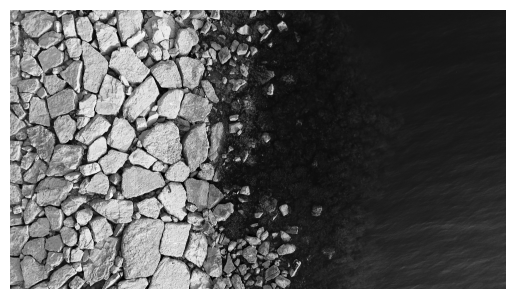

In [3]:
blockSize = 64
gridSize = int(pixelCount/blockSize)

def grayscale_cpu(src):
    gray = np.zeros((pixelCount, 3), dtype=src.dtype)

    for i in range(pixelCount):
        g = (float(src[i, 0]) + float(src[i, 1]) + float(src[i, 2])) / 3.0

        gray[i, 0] = g
        gray[i, 1] = g
        gray[i, 2] = g

    return gray

start_cpu = time.time()
gray = grayscale_cpu(flatten_image)
end_cpu = time.time()

cpu_time = end_cpu - start_cpu
print("CPU time:", cpu_time, "seconds")

gray_image_cpu = gray.reshape((h, w, 3))

plt.imshow(gray_image_cpu)
plt.axis('off')
plt.show()

In [4]:
@cuda.jit
def grayscale(src, dst):
#whereareweintheinput?
    tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    g = np.uint8((src[tidx, 0] + src[tidx,1] + src[tidx,2])/3)
    dst[tidx,0] = dst[tidx,1] = dst[tidx,2] = g

devSrc = cuda.to_device(flatten_image)
devDst = cuda.device_array((pixelCount, 3), np.uint8)

grayscale[gridSize, blockSize](devSrc, devDst)
hostDst = devDst.copy_to_host()

start_gpu = time.time()

grayscale[gridSize, blockSize](devSrc, devDst)
hostDst = devDst.copy_to_host()

end_gpu = time.time()

gpu_time = end_gpu - start_gpu

print("GPU time:", gpu_time, "seconds")

GPU time: 0.05051159858703613 seconds


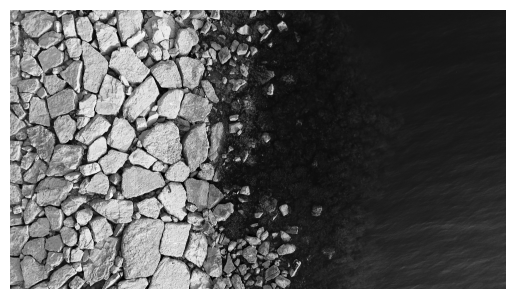

In [5]:
gray_image = hostDst.reshape((h, w, 3))

if gray_image.dtype in [np.float32, np.float64]:
    gray_image = np.clip(gray_image, 0.0, 1.0) 
else:
    # Nếu ảnh là số nguyên, ép về khoảng [0, 255] và kiểu uint8
    gray_image = np.clip(gray_image, 0, 255).astype(np.uint8)

plt.imshow(gray_image)
plt.axis('off')
plt.show()

In [6]:
block_sizes = [8, 16, 32, 64, 128, 256, 512]
gpu_times = []

for blockSize in block_sizes:
    gridSize = int(pixelCount / blockSize)
    devDst = cuda.device_array((pixelCount, 3), np.uint8)

    start = time.time()

    grayscale[gridSize, blockSize](devSrc, devDst)
    hostDst = devDst.copy_to_host()

    end = time.time()

    gpu_time = end - start

    gpu_times.append(gpu_time)

    print("Block size:", blockSize,
          "Time:", gpu_time)

Block size: 8 Time: 0.07519745826721191
Block size: 16 Time: 0.058357954025268555
Block size: 32 Time: 0.04838085174560547
Block size: 64 Time: 0.051351070404052734
Block size: 128 Time: 0.05149126052856445
Block size: 256 Time: 0.049405574798583984
Block size: 512 Time: 0.04916524887084961


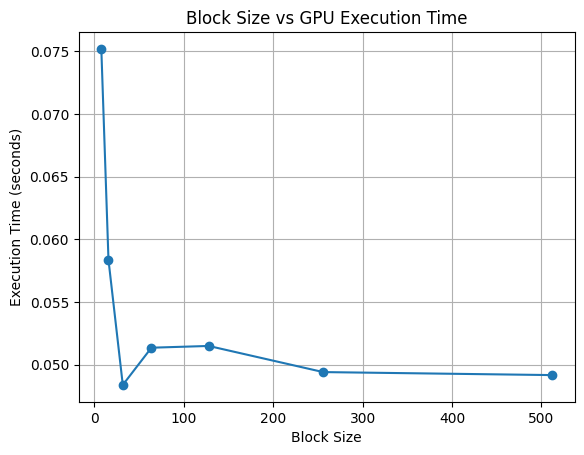

In [7]:
plt.plot(block_sizes, gpu_times, marker='o')

plt.xlabel("Block Size")
plt.ylabel("Execution Time (seconds)")
plt.title("Block Size vs GPU Execution Time")

plt.grid()
plt.show()
     